### 4a. Population Generation 

In [3]:
import random

def generate_population(n, d):
    
    population = [True] * d + [False] * (n - d)
    random.shuffle(population)
    return population

# Example usage
population = generate_population(1000, 100)
print(population)

[False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, True, True, True, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, True, False, False, False, False, False, False, True, False, False, True, True, False, False, False, False, False, False, False, False, True, False, False, False, False, False, False, True, False, True, False, False, False, False, True, False, False, True, False, False, False, False, False, False, False, True, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, True, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False

### 4b. Sample and Protocol Simulation

In [4]:
def apply_randomized_response(sample):
    
    responses = []
    
    for person in sample:
        first_flip = random.choice([True, False])  # True is heads, False is tails
        if first_flip:  # Heads
            second_flip = random.choice([True, False])  # Randomly respond True or False
            responses.append(second_flip)
        else:  # Tails
            responses.append(person)  # Report truthfully
        
    return responses

def simulate_protocol(population, sample_size):

    sample = random.sample(population, sample_size)
    return apply_randomized_response(sample)

# Example usage
responses = simulate_protocol(population, 50)
print(responses)

[False, True, False, False, True, True, False, False, False, False, False, True, False, False, False, False, False, True, True, False, False, False, False, False, False, True, True, False, False, False, False, False, False, True, False, False, False, False, False, False, False, False, True, True, True, False, True, False, True, False]


### 4c. Estimation function

In [5]:
def estimate_drug_users(n, d, sample_size):
    
    population = generate_population(n, d)
    responses = simulate_protocol(population, sample_size)
    
    # Calculate the fraction of "True" responses
    reported_true = responses.count(True)
    
    # Apply the formula to estimate the true fraction of drug users
    estimated_fraction = (reported_true / sample_size - 0.25) / 0.5
    
    # Estimate total drug users in population
    estimated_users = max(0, estimated_fraction * n)  # Handle negative estimates gracefully
    return estimated_users

# Example usage
estimated_users = estimate_drug_users(1000, 100, 50)

### 4d. Run a Simulation

In [6]:
# Run a simulation for the given parameters
population_size = 1000
drug_users = 100
sample_size = 50

estimated_users = estimate_drug_users(population_size, drug_users, sample_size)
print(f"Estimated number of drug users: {estimated_users}")

Estimated number of drug users: 300.00000000000006


### 4e. Explore Variability of Estimates

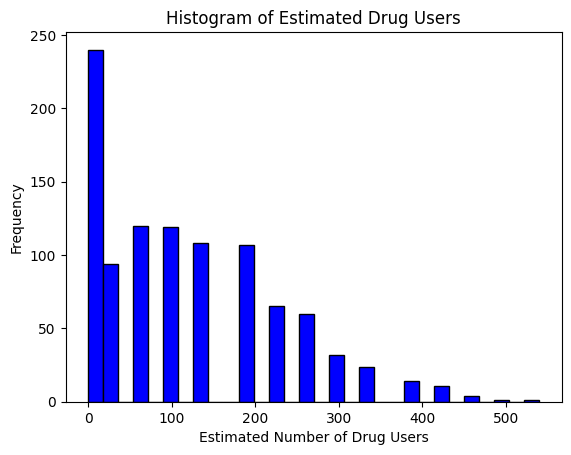

In [7]:
import numpy as np
import matplotlib.pyplot as plt

def run_multiple_simulations(n, d, sample_size, repetitions=1000):
  
    estimates = []
    for _ in range(repetitions):
        estimates.append(estimate_drug_users(n, d, sample_size))
    
    return estimates

# Run simulations and plot a histogram
estimates = run_multiple_simulations(1000, 100, 50, 1000)

plt.hist(estimates, bins=30, color='blue', edgecolor='black')
plt.title('Histogram of Estimated Drug Users')
plt.xlabel('Estimated Number of Drug Users')
plt.ylabel('Frequency')
plt.show()

### 4f. Explore Relationship Between Sample Size and Standard Deviation

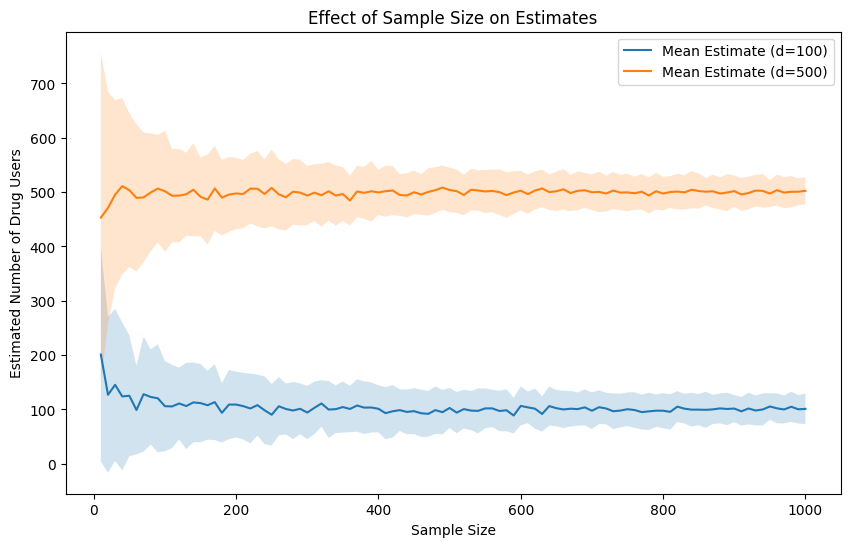

In [8]:
def explore_sample_size_variability(n, d_values, sample_size_range):
    
    mean_estimates = {d: [] for d in d_values}
    std_devs = {d: [] for d in d_values}
    
    for sample_size in sample_size_range:
        for d in d_values:
            estimates = run_multiple_simulations(n, d, sample_size, 100)
            mean_estimates[d].append(np.mean(estimates))
            std_devs[d].append(np.std(estimates))
    
    # Plot the results
    plt.figure(figsize=(10, 6))
    
    for d in d_values:
        plt.plot(sample_size_range, mean_estimates[d], label=f'Mean Estimate (d={d})')
        plt.fill_between(sample_size_range, 
                         np.array(mean_estimates[d]) - np.array(std_devs[d]), 
                         np.array(mean_estimates[d]) + np.array(std_devs[d]), 
                         alpha=0.2)
    
    plt.xlabel('Sample Size')
    plt.ylabel('Estimated Number of Drug Users')
    plt.title('Effect of Sample Size on Estimates')
    plt.legend()
    plt.show()

# Example usage
sample_size_range = list(range(10, 1001, 10))
explore_sample_size_variability(1000, [100, 500], sample_size_range)